# Data Visualization Part 2
## Advanced and Interactive Charts: Air Quality Index across Cities (2024)

This notebook uses **plotly** for interactive visualizations and **matplotlib / seaborn** for
advanced static charts. We work with a synthetic Air Quality Index (AQI) dataset
covering five cities over 12 months, enriched with PM2.5, humidity, and category labels.

Charts created:
1. **Interactive Scatter Plot** (Plotly) - AQI vs. PM2.5 with city color mapping
2. **Heatmap** (Seaborn) - Monthly AQI correlation matrix
3. **Box Plot** (Plotly) - AQI distribution by city
4. **Pie Chart** (Matplotlib) - Share of AQI categories

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Seaborn global style
sns.set_theme(style='white', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully')

Libraries loaded successfully


In [4]:
# Generate Synthetic Air-Quality Dataset
np.random.seed(7)

cities = ['Kyiv', 'London', 'New York', 'Tokyo', 'Sydney']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# AQI base values per city (higher = worse air quality)
aqi_bases = {'Kyiv': 70, 'London': 55, 'New York': 60, 'Tokyo': 50, 'Sydney': 40}

rows = []
for city in cities:
    for i, month in enumerate(months):
        # Seasonal modifier: winter months tend to have worse AQI
        seasonal = 15 * np.sin(np.pi * (i - 1) / 6)  # peaks in winter
        for _ in range(30):  # ~30 daily readings per month
            aqi = max(5, aqi_bases[city] + seasonal + np.random.normal(0, 18))
            pm25 = max(1, aqi * 0.4 + np.random.normal(0, 6))  # correlated with AQI
            humidity = np.clip(np.random.normal(60, 15), 20, 100)
            rows.append({
                'City': city,
                'Month': month,
                'Month_num': i + 1,
                'AQI': round(aqi, 1),
                'PM2.5': round(pm25, 1),
                'Humidity_%': round(humidity, 1)
            })

df = pd.DataFrame(rows)

# Categorise AQI values
def aqi_category(val):
    if val <= 50:
        return 'Good'
    elif val <= 100:
        return 'Moderate'
    elif val <= 150:
        return 'Unhealthy (Sensitive)'
    else:
        return 'Unhealthy'

df['Category'] = df['AQI'].apply(aqi_category)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1800, 7)


,City,Month,Month_num,AQI,PM2.5,Humidity_%,Category
0,Kyiv,Jan,1,92.9,34.4,60.5,Moderate
1,Kyiv,Jan,1,69.8,23.2,60.0,Moderate
2,Kyiv,Jan,1,62.5,14.5,75.3,Moderate
3,Kyiv,Jan,1,73.3,25.6,57.4,Moderate
4,Kyiv,Jan,1,71.6,27.1,56.4,Moderate


---
## 1. Interactive Scatter Plot - AQI vs. PM2.5

We use **Plotly Express** to create an interactive scatter plot where each point represents
a daily observation. Points are coloured by **city** and sized by **humidity**.
Hovering over a point reveals the exact values - a key advantage of interactive plots.

In [5]:
# 1. Interactive Scatter: AQI vs PM2.5
# Sample 600 points for readability in the scatter
df_sample = df.sample(n=600, random_state=42)

fig = px.scatter(
    df_sample,
    x='PM2.5',
    y='AQI',
    color='City',
    size='Humidity_%',
    hover_data=['Month', 'Category'],
    title='Air Quality Index vs. PM2.5 Concentration by City',
    labels={'PM2.5': 'PM2.5 (ug/m3)', 'AQI': 'Air Quality Index'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    opacity=0.7,
    template='plotly_white'
)

fig.update_layout(
    font=dict(size=13),
    legend_title_text='City',
    width=850,
    height=500
)

fig.show()

---
## 2. Heatmap - Monthly Average AQI by City

A **heatmap** encodes numeric values as colours in a matrix. Here the rows are cities
and columns are months, with colour intensity representing the average AQI.
This makes it easy to spot both the worst city-month combinations and seasonal trends.

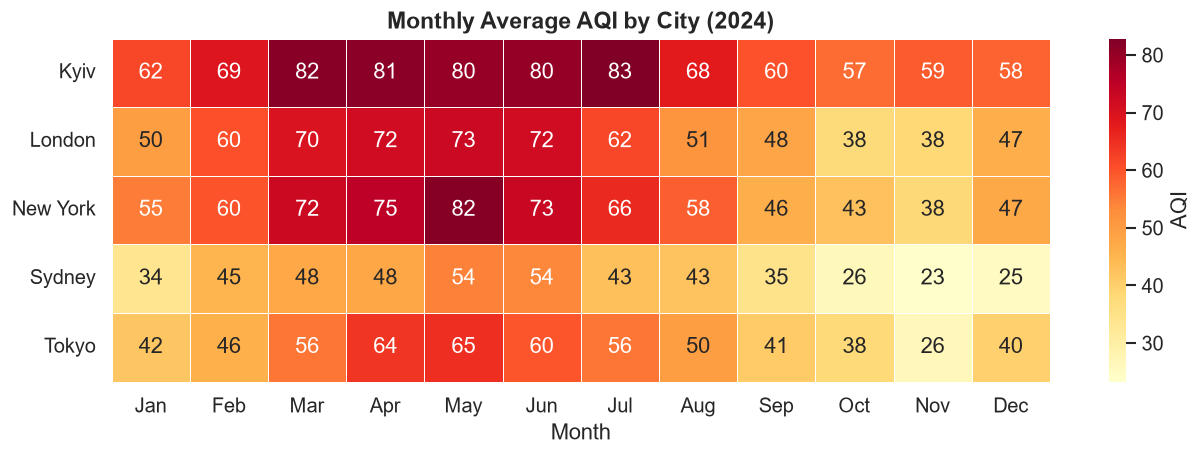

In [6]:
# 2. Heatmap: Monthly Average AQI
# Pivot table: rows = cities, columns = months
pivot = df.groupby(['City', 'Month_num'])['AQI'].mean().unstack()
pivot.columns = months  # rename columns to month names

fig, ax = plt.subplots(figsize=(11, 4))

sns.heatmap(
    pivot,
    annot=True,          # show numbers in cells
    fmt='.0f',           # integer format
    cmap='YlOrRd',       # yellow-orange-red palette
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'AQI'},
    ax=ax
)

ax.set_title('Monthly Average AQI by City (2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Month')

plt.tight_layout()
plt.show()

---
## 3. Interactive Box Plot - AQI Distribution by City

A **box plot** shows the median, quartiles, and outliers of a distribution.
Using Plotly makes it interactive - hover to see exact statistics.

In [7]:
# 3. Interactive Box Plot: AQI by City
fig = px.box(
    df,
    x='City',
    y='AQI',
    color='City',
    title='AQI Distribution by City (2024)',
    labels={'AQI': 'Air Quality Index'},
    color_discrete_sequence=px.colors.qualitative.Pastel,
    template='plotly_white',
    points='outliers'  # show only outlier points
)

fig.update_layout(
    font=dict(size=13),
    showlegend=False,
    width=750,
    height=480
)

fig.show()

---
## 4. Pie Chart - Overall AQI Category Breakdown

A **pie chart** shows proportions of a whole. Here we display the share of all daily
readings falling into each AQI category across all cities combined.

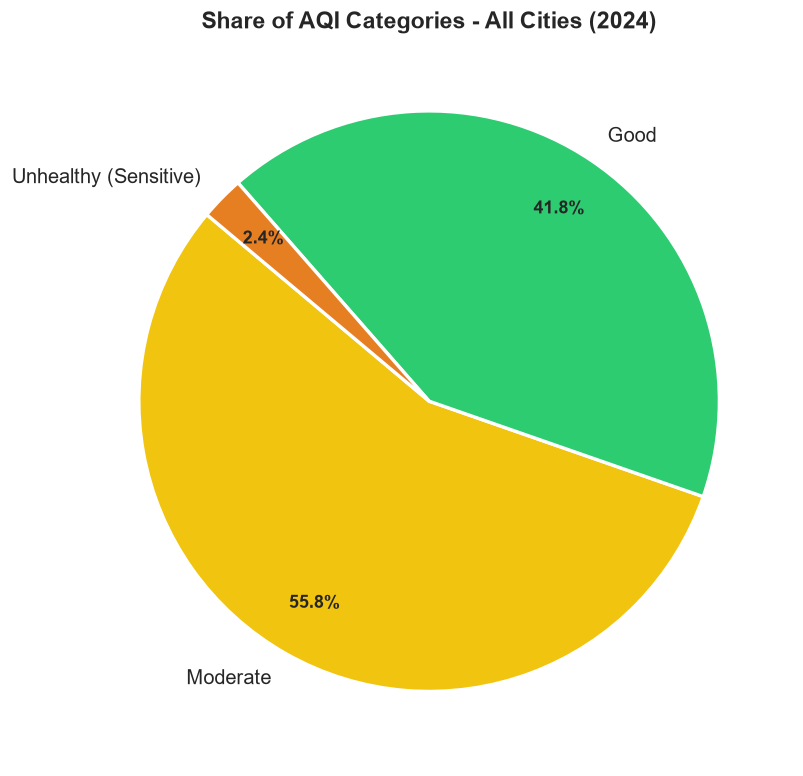

In [8]:
# 4. Pie Chart: AQI Category Shares
category_counts = df['Category'].value_counts()

# Custom colours matching AQI severity
cat_colors = {
    'Good': '#2ecc71',
    'Moderate': '#f1c40f',
    'Unhealthy (Sensitive)': '#e67e22',
    'Unhealthy': '#e74c3c'
}
colors = [cat_colors.get(c, '#95a5a6') for c in category_counts.index]

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Style percentage labels
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax.set_title('Share of AQI Categories - All Cities (2024)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Conclusion

### Key Insights from the Visualizations

1. **AQI and PM2.5 are strongly correlated** - the scatter plot shows a clear positive
   linear trend, confirming that particulate matter is a primary driver of overall air quality.

2. **Sydney has the cleanest air** - both the heatmap and box plot consistently place Sydney
   at the lowest AQI values (median around 40), while **Kyiv records the highest readings**
   (median around 70-85), likely driven by seasonal heating emissions.

3. **Seasonal patterns are visible** - the heatmap reveals that winter months (Jan, Feb, Nov, Dec)
   tend to have elevated AQI across most cities, aligning with higher heating demand and
   atmospheric inversion conditions.

4. **The majority of readings fall into the Moderate category** - the pie chart shows that most
   daily observations sit between AQI 51-100, with only a small fraction reaching unhealthy levels.

5. **Interactive visualizations enhance exploration** - Plotly charts allow users to hover,
   zoom, and filter, making it easier to drill into specific city-month combinations
   than static charts alone.

---
*End of Notebook 2*